# Exploration des Digits - Dévoiler les secrets numériques
## Introduction
Pour cette nouvelle mission nous avons été chargé de découvrir l'ensemble de donnée _Digits_. Celui-ci contient plusieurs images normalisées de dimension 8x8 sur un grayscale de 0 à 16. 

Notre objectif est clair: apprendre à nos modèles à classifier les nombres affichés sur chaque image entre les classe 0 à 9 et les optimiser pour obtenir les meilleures performances. C'est un défi de taille mais grâce à nos nouvelles habilités de data analysts en herbe, nous allons le relever!

## 1. Exploration des données

Data shape: (1797, 64) (Number of samples, Number of pixels)
Target shape: (1797,)


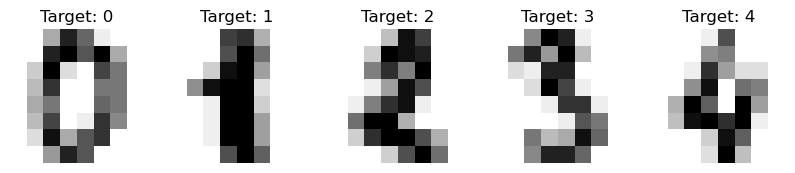

In [7]:
# ------------------------------------------
# 1. Imports and Data Loading
# ------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

digits = load_digits()
X = digits.data
y = digits.target

print(f"Data shape: {X.shape} (Number of samples, Number of pixels)")
print(f"Target shape: {y.shape}")

# On visualise les premiers chiffres du dataset
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f"Target: {y[i]}")
    ax.axis('off')
plt.show()

Au-delà du simple fait de regarder les images, nous devons comprendre la distribution statistique de notre ensemble de données pour nous assurer qu'il n'y a pas de déséquilibres ou d'anomalies graves dans les intensités des pixels.

=== Class Distribution ===
Digit 0: 178 samples
Digit 1: 182 samples
Digit 2: 177 samples
Digit 3: 183 samples
Digit 4: 181 samples
Digit 5: 182 samples
Digit 6: 181 samples
Digit 7: 179 samples
Digit 8: 174 samples
Digit 9: 180 samples


/var/folders/wv/63dfw63525l83xs7nczjjy3m0000gn/T/ipykernel_38098/4285141713.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


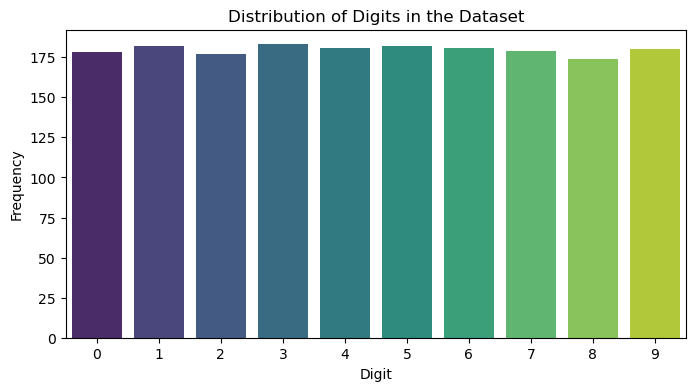


=== Pixel Intensity Statistics ===
Global Maximum pixel value: 16.0
Global Minimum pixel value: 0.0
Global Mean pixel value: 4.88

Data split: 1437 training samples, 360 testing samples.


In [8]:
# 1. Verifier la distribution des données dans la classe
print("=== Class Distribution ===")
class_counts = pd.Series(y).value_counts().sort_index()
for digit, count in class_counts.items():
    print(f"Digit {digit}: {count} samples")

# Plot le graphe associé
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Digits in the Dataset")
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.show()

# 2. Statistiques sur l'intensité des pixel
print("\n=== Pixel Intensity Statistics ===")
print(f"Global Maximum pixel value: {X.max()}")
print(f"Global Minimum pixel value: {X.min()}")
print(f"Global Mean pixel value: {X.mean():.2f}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nData split: {X_train.shape[0]} training samples, {X_test.shape[0]} testing samples.")

## 2. Feature Engineering & Preprocessing

Afin de ne garder que le nombre de signaux nécessaire pour l'ACP, nous utiliserons la "méthode du coude" pour trouver le nombre optimal de composants. Nous voulons réduire la dimension de 64 pixels tout en conservant au moins 95 % de la variance.

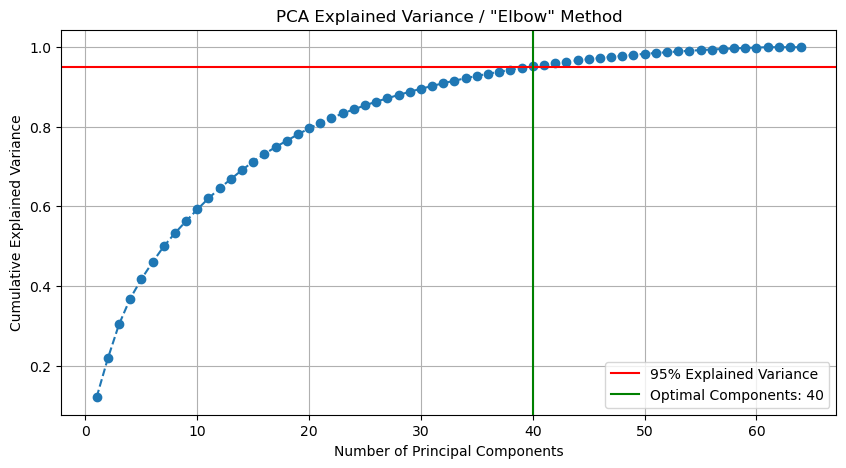

Pour avoir 95% de l'information, on doit garder 40 composants sur les 64.


In [9]:
# Scale the training data temporarily for this analysis
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit PCA on the scaled data without limiting components (max is 64)
pca_analysis = PCA()
pca_analysis.fit(X_train_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_analysis.explained_variance_ratio_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')

# Find the exact number of components that cross the 95% threshold
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
plt.axvline(x=optimal_components, color='g', linestyle='-', label=f'Optimal Components: {optimal_components}')

plt.title('PCA Explained Variance / "Elbow" Method')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(f"Pour avoir 95% de l'information, on doit garder {optimal_components} composants sur les 64.")

## 3. Modélisation et optimisation

Nous allons construire un pipeline pour enchaîner notre StandardScaler, PCA et KNeighborsClassifier. Pour nous assurer d'atteindre la plus grande précision possible, nous utiliserons GridSearchCV pour tester automatiquement plusieurs combinaisons d'hyper-paramètres pour le modèle PCA et pour chaque modèle testé.

### A. k-Nearest Neighbors (k-NN)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# 1. Definir la pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()), 
    ('knn', KNeighborsClassifier())
])

# 2. Define the Grid of parameters to test
# Notice the syntax: stepname__parametername
param_grid = {
    'pca__n_components': [15, 20, 25, 30, 40], # On teste autour de notre coude
    'knn__n_neighbors': [3, 5, 7, 9, 11],      # On teste pour différents n voisins
    'knn__weights': ['uniform', 'distance']    # Testing how neighbors vote
}

# 3. Setup de GridSearchCV
print("Starting GridSearch Optimization... This might take a few seconds.")
grid_search = GridSearchCV(
    estimator=knn_pipeline, 
    param_grid=param_grid, 
    cv=5,            # 5-fold cross-validation for robustness
    scoring='accuracy',
    n_jobs=-1        # Use all processor cores
)

# 4. Entrainement du GridSearch
grid_search.fit(X_train, y_train)

# 5. Extraire le meilleur modèle
best_knn_model = grid_search.best_estimator_

print("\n=== Résultats du GridSearch ===")
print(f"Les meilleurs paramètres trouvés sont: {grid_search.best_params_}")
print(f"Meilleure précision pour la cross-validation : {grid_search.best_score_ * 100:.2f}%")

Starting GridSearch Optimization... This might take a few seconds.

=== Résultats du GridSearch ===
Les meilleurs paramètres trouvés sont: {'knn__n_neighbors': 3, 'knn__weights': 'uniform', 'pca__n_components': 40}
Meilleure précision pour la cross-validation : 97.56%


## 4. Evaluation et analyse des performances

## 5. Conclusion